In [2]:
import sys,copy,os,inspect
if hasattr(sys.modules[__name__], '__file__'):
    _file_name = __file__
else:
    _file_name = inspect.getfile(inspect.currentframe())
CURRENT_FILE_PATH = os.path.dirname(_file_name)
sys.path.append(os.getcwd()+"/../neuronVis")

import IONData,Scene,SwcLoader
import NeuronProcess
from sklearn.cluster import KMeans
import numpy as np
import joblib

def GetFirstOrderEdges(edgesForCluster,parentedge):
    for child in parentedge.children:
        if child.order!=0:
            edge = SwcLoader.Edge()
            edgesForCluster.append(edge)
            for p in child.data:
                edge.addPoint(SwcLoader.Point([p.index,p.type,p.x,p.y,p.z,p.ratio,p.parentIndex]))
            child.maxDepth=1
            GetFirstOrderEdges(edgesForCluster,child)
#In[0]


import Visual as nv
import json
# neuronvis = nv.neuronVis(renderModel=1)

# neuronvis.render.setBackgroundColor((0.0,0.20,0.5,1.0))
# neuronvis.addRegion('CA1',[0.5,1.0,0.5])
iondata = IONData.IONData()
# f=open('../resource/pfcsubtype60.json', encoding='gbk')
# neurons=[]
# neurons = json.load(f)
# neurons=iondata.getNeuronListBySampleID('211190')
neurons= Scene.scene2List('../resource/scene/cluster5_spcd20220628_spcd.nv')
# neuronvis.render.setLookAt((5000,0,15000),(5000,0,0),(0,-1,0))

edgesForCluster=[]

for neuron in neurons[0:-1]:
    print(neuron['sampleid'], neuron['name'])
    neuronT = iondata.getNeuronTreeByID(neuron['sampleid'], neuron['name'])
    neuronT.dendriteHide=True
    NeuronProcess.CalculateBranchMaxDepth(neuronT)
    mainbranch=[]
    if neuronT.rootAxonEdge is None:
        continue
    for edge in neuronT.edges:

        if edge.maxDepth>neuronT.rootAxonEdge.maxDepth*0.5:
            edge.order=0
            mainbranch.append(edge)
    for edge in mainbranch:
        for child in edge.children:
            if child.order!=0:
                NeuronProcess.OrderChildren(neuronT,child,1)
        pass
    # for child in neuronT.rootAxonEdge.children:
    # 	# if child.order!=0:
    # 		NeuronProcess.OrderChildren(neuronT,child,1)

    for edge in mainbranch:
        for child in edge.children:
            if child.order!=0:
                GetFirstOrderEdges(edgesForCluster,child)

newneuron=SwcLoader.NeuronTree()
if len(mainbranch):
    newneuron.edges= edgesForCluster
    newneuron.rootAxonEdge = neuronT.rootAxonEdge
    newneuron.root=neuronT.root
# neuronvis.addNeuronTree(newneuron,'neuronname',depthIntensity=False)
# neuronvis.clear()
data = []
for edge in edgesForCluster:
    xyz=[]
    edge.children=[]
    for point in edge.data:
        xyz.append(point.xyz)
    # print(np.array(xyz).mean(axis=0))
    data.append(np.array(xyz).mean(axis=0))
cluster=5
# print(data)
estimator=KMeans(n_clusters=cluster,max_iter=1500)
res=estimator.fit_predict(data)
# 预测类别标签结果
lable_pred=estimator.labels_
# 各个类别的聚类中心值
centroids=estimator.cluster_centers_
# 聚类中心均值向量的总和
inertia=estimator.inertia_
print(lable_pred)
for i in range(len(edgesForCluster)):
    edge=edgesForCluster[i]
    edge.maxDepth=lable_pred[i]
neuronT.rootAxonEdge.maxDepth=4
newneuron=SwcLoader.NeuronTree()
# if len(edgesForCluster):
#     newneuron.edges= edgesForCluster
#     newneuron.rootAxonEdge = neuronT.rootAxonEdge
#     newneuron.root=neuronT.root
#     neuronvis.addNeuronTree(newneuron,'t',depthIntensity=True)
# neuronvis.render.savepng('../resource/test42.png')
# neuronvis.render.run()


#In[1]


202568 005.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/202568/005.swc
202568 011.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/202568/011.swc
202568 013.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/202568/013.swc
202568 017.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/202568/017.swc
202568 021.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/202568/021.swc
202568 022.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/202568/022.swc
202568 009.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/202568/009.swc
210728 001.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210728/001.swc
210728 002.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210728/002.swc
210728 003.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/.

In [2]:
res,path = iondata.getFileFromServer("IB_MP_P_MY.nrrd")
import nrrd
IB_MP_P_MYmap,header = nrrd.read(path)

In [40]:
clusterLength={}
for c in range(5):
    clusterLength[c]={0:0,354:0,771:0,313:0,1129:0}
for i in range(len(edgesForCluster)):
    edge=edgesForCluster[i]
    lenMap ={0:0,354:0,771:0,313:0,1129:0}
    for j in range(len(edge.data)-1):
        p = edge.data[j]
        if int(p.x/10)<IB_MP_P_MYmap.shape[0]:
            region = IB_MP_P_MYmap[int(p.x/10),int(p.y/10),int(p.z/10)]
        else:
            region=0
        length = np.linalg.norm(np.array(edge.data[j].xyz)-np.array(edge.data[j+1].xyz))
        lenMap[region]+=length
    for k,v in lenMap.items():
        clusterLength[edge.maxDepth][k]+=v


[0.1267890713494533, 0.0, 0.0002458581360398717, 0.6297087866602614, 1.0]
0.35134874322915094 0.39884307395603585 [6.78574433e-001 2.66540469e-001 1.94902976e-004 2.65315994e-010
 6.72354074e-019 3.17192053e-030 2.78571192e-044 4.55449002e-061
 1.38622254e-080 7.85445045e-103 8.28491966e-128 1.62686099e-155
 5.94705888e-186 4.04709761e-219 5.12713518e-255]
[0.2360189345362709, 1.0, 0.009141924587550377, 0.0012882537314322137, 0.0]
0.2492898225710507 0.3860215262533808 [8.38953168e-001 1.55972348e-001 3.53082554e-005 9.73248336e-012
 3.26655398e-021 1.33498003e-033 6.64321726e-049 4.02532456e-067
 2.96990194e-088 2.66809984e-112 2.91864183e-139 3.88757058e-169
 6.30513706e-202 1.24517254e-237 2.99421719e-276]
[0.01678437860977126, 0.00014036518817409335, 0.03530458172980044, 1.0001403651881742, 0.0002448980186736376]
0.2105229177469187 0.39502138274508963 [8.76221845e-001 1.37070469e-001 3.53249978e-005 1.49978433e-011
 1.04902032e-020 1.20878041e-032 2.29466528e-047 7.17628537e-065
 3.

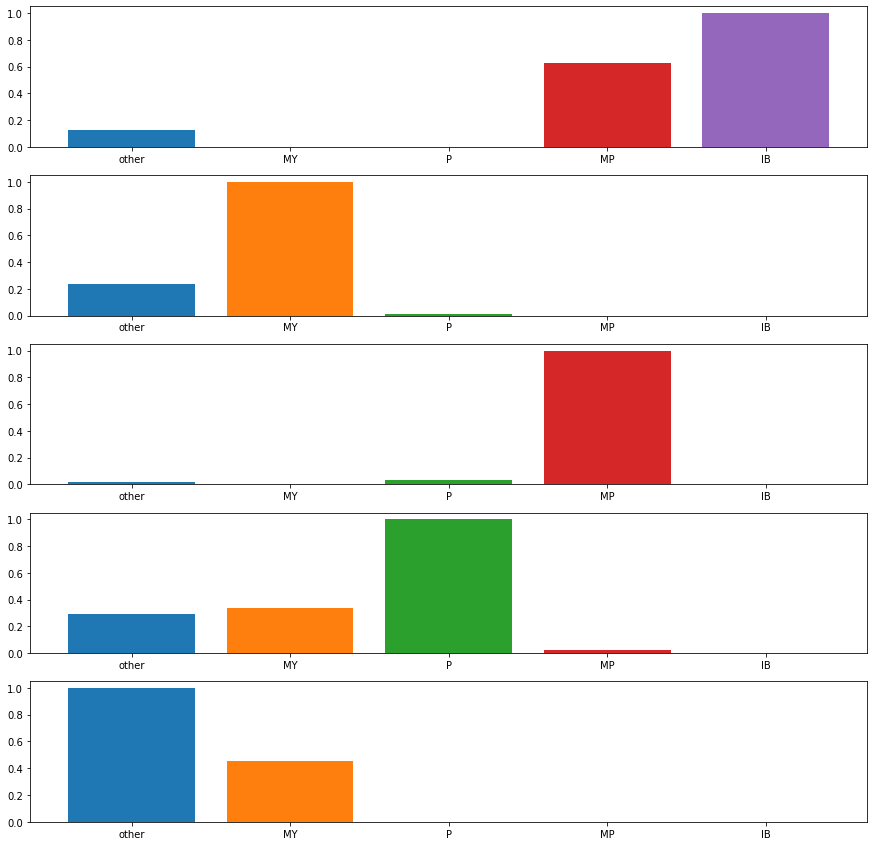

In [50]:
clusterLength
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
matplotlib.use('module://matplotlib_inline.backend_inline')
%matplotlib inline
import seaborn as sns
from scipy.stats import norm

def Normalize(data):
    m = np.mean(data)
    mx = max(data)
    mn = min(data)
    return [(float(i)) / (mx - mn) for i in data]

plt.figure(figsize=(15,15))
for j in range(5):
    plt.subplot(5,1,j+1)
    x= Normalize(np.array(list(clusterLength[j].values())))
    print(x)
    for i in range(len(x)):
        plt.bar(i, x[i])
        plt.xticks( range(5),['other','MY','P','MP','IB'])
    mu =np.mean(x)
    sigma =np.std(x)
    y = norm.pdf(range(15), mu, sigma)#拟合一条最佳正态分布曲线y 
    print(mu,sigma,y)
    # plt.plot(range(15), y, 'r--') #绘制y的曲线
plt.show()

## mainbranch



In [1]:
import sys,copy,os,inspect
if hasattr(sys.modules[__name__], '__file__'):
    _file_name = __file__
else:
    _file_name = inspect.getfile(inspect.currentframe())
CURRENT_FILE_PATH = os.path.dirname(_file_name)
sys.path.append(os.getcwd()+"/../neuronVis")

import IONData,Scene,SwcLoader
import NeuronProcess
from sklearn.cluster import KMeans
import numpy as np
import joblib
import pandas as pd

def loadClusterCSV(filename,cluster=None):
    neurons = pd.read_csv(filename)
    neuronsArray= neurons.to_numpy()
    neuronScene=[]
    for neuron in neuronsArray:
        # print(str(neuron[2])[0])
        neurondict={}
        neurondict['cluster'] = neuron[1]
        neurondict['sampleid'] = str(neuron[2])[0:6]
        neurondict['name']=str(neuron[2])[6:]+'.swc'
        if cluster ==neuron[1] or cluster ==None:
            neuronScene.append(neurondict)
    return neuronScene

def GetFirstOrderEdges(edgesForCluster,parentedge):
    for child in parentedge.children:
        if child.order!=0:
            edge = SwcLoader.Edge()
            edgesForCluster.append(edge)
            for p in child.data:
                edge.addPoint(SwcLoader.Point([p.index,p.type,p.x,p.y,p.z,p.ratio,p.parentIndex]))
            child.maxDepth=1
            GetFirstOrderEdges(edgesForCluster,child)


import Visual as nv
import json
neuronvis = nv.neuronVis(renderModel=0)

neuronvis.render.setBackgroundColor((0.0,0.0,0.,1.0))
iondata = IONData.IONData()
neurons = loadClusterCSV('../resource/cluster_eachNeuron/cluster_eachNeuron_spcd.csv',cluster=8)
neuronvis.render.setLookAt((5000,-15000,0),(5000,0,0),(0,0,-1))
mainbranchs=[]
edgesForCluster=[]
for neuron in neurons[7:-1]:
    print(neuron['sampleid'], neuron['name'])
    # neuronT = iondata.getNeuronTreeByID('211467','023.swc')
    neuronT = iondata.getNeuronTreeByID(neuron['sampleid'], neuron['name'])
    neuronT.dendriteHide=True
    NeuronProcess.CalculateBranchMaxDepth(neuronT)
    mainbranch=[]
    if neuronT.rootAxonEdge is None:
        continue
    for edge in neuronT.edges:

        if edge.maxDepth>neuronT.rootAxonEdge.maxDepth*0.5:
            edge.order=0
            mainbranch.append(edge)
    for edge in mainbranch:
        for child in edge.children:
            if child.order!=0:
                NeuronProcess.OrderChildren(neuronT,child,1)
        pass
    # for child in neuronT.rootAxonEdge.children:
    # 	# if child.order!=0:
    # 		NeuronProcess.OrderChildren(neuronT,child,1)

    for edge in mainbranch:
        for child in edge.children:
            if child.order!=0:
                GetFirstOrderEdges(edgesForCluster,child)
    mainbranchs.append(mainbranch)
    newneuron=SwcLoader.NeuronTree()
    if len(mainbranch):
        newneuron.edges= mainbranch
        newneuron.rootAxonEdge = neuronT.rootAxonEdge
        newneuron.root=neuronT.root
    neuronvis.addNeuronTree(newneuron,'neuronname',depthIntensity=False)

neuronvis.render.run()

202568 001.swc
210731 043.swc
211185 007.swc
211185 010.swc
211186 001.swc
211186 003.swc
211188 012.swc
211467 016.swc
211467 017.swc
211467 018.swc
211467 019.swc
211467 023.swc
211467 028.swc
211467 032.swc
211467 034.swc
211468 039.swc
211468 062.swc
211468 069.swc
211470 048.swc
211472 004.swc
211473 002.swc
211988 021.swc
211466 016.swc
211467 013.swc
210728 045.swc


In [1]:

import GeometryAdapter

neuronvis = nv.neuronVis(renderModel=0)
neuronvis.render.setBackgroundColor((1.0,1.0,1.,1.0))
neuronvis.render.setLookAt((5000,-15000,0),(5000,0,0),(0,0,-1))
points=[]
branchpoints=[]
for mainbranch in mainbranchs[:]:
    for edge in mainbranch:
        pre = None
        for p in edge.data:
            if pre is not None :
                if (pre.z-5700)*(p.z-5700)<0:
                    points.append(p)

                    count=0
                    parent = edge.parent
                    if parent:
                        while count<1:
                            for child in parent.children:
                                if child in mainbranch:
                                    count+=1
                            if count>1:
                                branchpoints.append(parent.data[len(parent.data)-1])
                            if parent.parent and count==1:
                                parent = parent.parent
                                count=0
                    
                    
            pre = p
    newneuron.edges= mainbranch
    newneuron.rootAxonEdge = neuronT.rootAxonEdge
    newneuron.root=neuronT.root
    newneuron.somaRadius=100
    neuronvis.addNeuronTree(newneuron,name='neuronname',color=[1.0,0.0,0.0],depthIntensity=False)


ga = GeometryAdapter.GeometryAdapter()
for i in range(len(points)):
    ga.geometry.addPoint([points[i].x,points[i].y,points[i].z],[0.0,.0,1.0])
    ga.geometry.addIndex(i)
ga.geometry.drawModel='points'
neuronvis.render.addGeometry(ga.geometry)

ga0 = GeometryAdapter.GeometryAdapter()
for i in range(len(branchpoints)):
    ga0.geometry.addPoint([branchpoints[i].x,branchpoints[i].y,branchpoints[i].z],[0.0,1.0,.0])
    ga0.geometry.addIndex(i)
ga0.geometry.drawModel='points'
neuronvis.render.addGeometry(ga0.geometry)

neuronvis.render.setPointSize(10)

neuronvis.render.run()

ModuleNotFoundError: No module named 'GeometryAdapter'